In [1]:
# Tutorial on Pandas https://www.youtube.com/watch?v=Iqjy9UqKKuo&list=PLQVvvaa0QuDc-3szzjeP6N6b0aDrrKyL-

In [2]:
import pandas as pd
import datetime
import pandas.io.data as web
import matplotlib.pyplot as plt
from matplotlib import style

style.use('ggplot')

start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

df = web.DataReader("XOM", "yahoo", start, end)

print(df.head())

df['Adj Close'].plot()
plt.show()

ModuleNotFoundError: No module named 'pandas.io.data'

In [ ]:
pip install pandas.io.data

In [ ]:
import datetime
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from matplotlib import style

style.use('fivethirtyeight')

start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.now()

df = web.DataReader("XOM", "morningstar", start, end)

df.reset_index(inplace=True)
df.set_index("Date", inplace=True)
df = df.drop("Symbol", axis=1)

print(df.head())

df['High'].plot()
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import pandas_datareader.data as web  # Updated import
import datetime
import matplotlib.pyplot as plt
from matplotlib import style

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

df = web.DataReader("XOM", "yahoo", start, end)
print(df.head())
df['Adj Close'].plot()
plt.show()

In [ ]:
pip install pandas-datareader

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt
from matplotlib import style

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()
df = web.DataReader("XOM", "yahoo", start, end)
print(df.head())
df['Adj Close'].plot()
plt.show()


In [ ]:
import datetime
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from matplotlib import style

style.use('fivethirtyeight')

start = datetime.datetime(2024, 1, 1)
end = datetime.datetime.now()

df = web.DataReader("XOM", "yahoo", start, end)

df.reset_index(inplace=True)
df.set_index("Date", inplace=True)
df = df.drop("Symbol", axis=1)

print(df.head())

df['High'].plot()
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import datetime

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

# Fetch XOM data using yfinance
df = yf.download("XOM", start=start, end=end)
print(df.head())
df['Adj Close'].plot()
plt.show()


In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import datetime

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

# Fetch XOM data using yfinance
df = yf.download("XOM", start=start, end=end)
print(df.head())
df['Adj Close'].plot()
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import datetime

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

df = yf.download("XOM", start=start, end=end)

# Flatten MultiIndex columns to match your original expectation
df.columns = df.columns.droplevel(1)  # Remove 'Ticker' level
print(df.head())
df['Adj Close'].plot()  # Now works!
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import datetime

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

df = yf.download("^NSEI", start=start, end=end)

# Correct column flattening - rename to match your expectation
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close'][:len(df.columns)]
print(df.head())
df['Close'].plot()  # or df['Adj Close'].plot()
plt.show()


In [ ]:
#The above is working good.

In [ ]:
nifty = yf.download('^NSEI', interval='5m', period='5d')
nifty['signal'] = (nifty['Close'] > nifty['Close'].shift(1)).map({True:'GREEN', False:'RED'})

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import datetime

style.use('ggplot')
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime.now()

nifty = yf.download('^NSEI', interval='5m', period='5d')
nifty['signal'] = (nifty['Close'] > nifty['Close'].shift(1)).map({True:'GREEN', False:'RED'})

# Correct column flattening - rename to match your expectation
nifty.columns = ['Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close'][:len(df.columns)]
print(nifty.head())
nifty['Close'].plot()  # or df['Adj Close'].plot()
plt.show()

In [ ]:
##2nd exercise

In [3]:
import pandas as pd
df = pd.read_csv('trading_signals.csv', parse_dates=['timestamp'])
df['returns'] = df['close'].pct_change()
df = df.dropna().reset_index(drop=True)
df['volatility'] = df['returns'].rolling(20).std(); 
df['volume_ma'] = df['volume'].rolling(20).mean()
df.to_csv('clean_trading_data.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'trading_signals.csv'

In [5]:
df = pd.read_csv('trading_signals.csv'); print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'trading_signals.csv'

In [9]:
import pandas as pd
df = pd.read_csv(r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv', parse_dates=['timestamp'])
df['returns'] = df['close'].pct_change()
df = df.dropna().reset_index(drop=True)
df['volatility'] = df['returns'].rolling(20).std() 
df['volume_ma'] = df['volume'].rolling(20).mean()
df.to_csv('clean_trading_data.csv', index=False)
print("Data processed successfully!")
print(df.head())


Data processed successfully!
            timestamp      symbol    close   volume signal   returns  \
0 2026-03-18 13:25:00  WAAREEENER  3160.70  6089133    BUY  6.180961   
1 2026-03-18 13:25:00   WAAREERTL   861.00   460208    BUY -0.727592   
2 2026-03-18 13:25:00     TIINDIA  2574.00   394278    BUY  1.989547   
3 2026-03-18 13:25:00  BANDHANBNK   163.54  5937235    BUY -0.936465   
4 2026-03-18 13:25:00       ROUTE   488.55  7723168   SELL  1.987343   

   volatility  volume_ma  
0         NaN        NaN  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN        NaN  


C:\Users\Kuro Gaming\AppData\Local\Temp\ipykernel_2668\2058389122.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv', parse_dates=['timestamp'])


In [8]:
import pandas as pd
import os

# Verify file exists and check columns
filepath = r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

# Read WITHOUT date parsing to see actual column names
df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

File exists: True
Actual columns: ['Timestamp', 'Symbol', 'Close', 'Volume', 'Signal']

First few rows:
          Timestamp      Symbol    Close   Volume Signal
0  18-03-2026 13:25        HEXT   440.15  2518696    BUY
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133    BUY
2  18-03-2026 13:25   WAAREERTL   861.00   460208    BUY
3  18-03-2026 13:25     TIINDIA  2574.00   394278    BUY
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235    BUY


In [11]:
import pandas as pd
import os

# Verify file exists and check columns
filepath = r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

#Core code
df['returns'] = df['close'].pct_change()

#Handle issues
df = df.dropna().reset_index(drop=True)

#3 features
 df['volatility'] = df['returns'].rolling(20).std(); 
 df['volume_ma'] = df['volume'].rolling(20).mean()

# Read WITHOUT date parsing to see actual column names
df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

#Save
df.to_csv('clean_trading_data.csv', index=False)

IndentationError: unexpected indent (1738324869.py, line 15)

In [12]:
import pandas as pd
import os

# Verify file exists and check columns
filepath = r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

# Read data FIRST (must load before using df)
df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Core code - FIXED column names (Capital letters from your CSV)
df['returns'] = df['Close'].pct_change()

# Handle issues
df = df.dropna().reset_index(drop=True)

# 3 features
df['volatility'] = df['returns'].rolling(20).std()
df['volume_ma'] = df['Volume'].rolling(20).mean()

# Save processed trading signals
df.to_csv('clean_trading_data.csv', index=False)
print("\n✅ Trading signals processed successfully!")
print("Output saved as: clean_trading_data.csv")


File exists: True
Actual columns: ['timestamp', 'symbol', 'close', 'volume', 'signal']

First few rows:
          timestamp      symbol    close   volume signal
0  18-03-2026 13:25        HEXT   440.15  2518696    BUY
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133    BUY
2  18-03-2026 13:25   WAAREERTL   861.00   460208    BUY
3  18-03-2026 13:25     TIINDIA  2574.00   394278    BUY
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235    BUY


KeyError: 'Close'

In [13]:
import pandas as pd
import os

# Verify file exists
filepath = r'C:\Users\Kuro Gaming\Data Stience\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

# Read data FIRST
df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Core code - MATCHES YOUR ACTUAL lowercase columns
df['returns'] = df['close'].pct_change()

# Handle issues
df = df.dropna().reset_index(drop=True)

# 3 features - lowercase column names
df['volatility'] = df['returns'].rolling(20).std()
df['volume_ma'] = df['volume'].rolling(20).mean()

# Save processed trading signals
df.to_csv('clean_trading_data.csv', index=False)
print("\n✅ Trading signals processed successfully!")
print("Output saved as: clean_trading_data.csv")


File exists: True
Actual columns: ['timestamp', 'symbol', 'close', 'volume', 'signal']

First few rows:
          timestamp      symbol    close   volume signal
0  18-03-2026 13:25        HEXT   440.15  2518696    BUY
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133    BUY
2  18-03-2026 13:25   WAAREERTL   861.00   460208    BUY
3  18-03-2026 13:25     TIINDIA  2574.00   394278    BUY
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235    BUY

✅ Trading signals processed successfully!
Output saved as: clean_trading_data.csv


In [15]:
import pandas as pd
import os

filepath = r'C:\\Users\\Kuro Gaming\\Data Stience\\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows (raw):")
print(df.head())

# Compute features
df['returns'] = df['close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['volume_ma'] = df['volume'].rolling(20).mean()

df = df.dropna().reset_index(drop=True)

# Save ALL columns (including new ones)
df.to_csv('clean_trading_data.csv', index=False)

print("\nFirst few rows (with features):")
print(df.head())

print("\n✅ Trading signals processed successfully!")
print("Output saved as: clean_trading_data.csv")


File exists: True
Actual columns: ['timestamp', 'symbol', 'close', 'volume', 'signal']

First few rows (raw):
          timestamp      symbol    close   volume signal
0  18-03-2026 13:25        HEXT   440.15  2518696    BUY
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133    BUY
2  18-03-2026 13:25   WAAREERTL   861.00   460208    BUY
3  18-03-2026 13:25     TIINDIA  2574.00   394278    BUY
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235    BUY

First few rows (with features):
          timestamp      symbol    close   volume signal   returns  \
0  18-03-2026 13:35     OLECTRA  1032.45  4953823    BUY  0.234988   
1  18-03-2026 13:35  CONCORDBIO  1147.90   316437    BUY  0.111821   
2  18-03-2026 13:35   JINDALSAW   198.92  2388029    BUY -0.826710   
3  18-03-2026 13:35  ADANIGREEN   896.90  1744215    BUY  3.508848   
4  18-03-2026 13:35      ENTERO  1134.40   167513    BUY  0.264801   

   volatility   volume_ma  
0    2.463844  4630097.05  
1    2.168486  4341462.25  
2    2.172

In [16]:
#Practice part is done

File exists: True
Actual columns: ['timestamp', 'symbol', 'close', 'volume', 'signal']

First few rows (raw):
          timestamp      symbol    close   volume signal
0  18-03-2026 13:25        HEXT   440.15  2518696    BUY
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133    BUY
2  18-03-2026 13:25   WAAREERTL   861.00   460208    BUY
3  18-03-2026 13:25     TIINDIA  2574.00   394278    BUY
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235    BUY

First few rows (with features):
          timestamp      symbol    close   volume signal   returns  \
0  18-03-2026 13:35     OLECTRA  1032.45  4953823    BUY  0.234988   
1  18-03-2026 13:35  CONCORDBIO  1147.90   316437    BUY  0.111821   
2  18-03-2026 13:35   JINDALSAW   198.92  2388029    BUY -0.826710   
3  18-03-2026 13:35  ADANIGREEN   896.90  1744215    BUY  3.508848   
4  18-03-2026 13:35      ENTERO  1134.40   167513    BUY  0.264801   

   volatility   volume_ma  
0    2.463844  4630097.05  
1    2.168486  4341462.25  
2    2.172

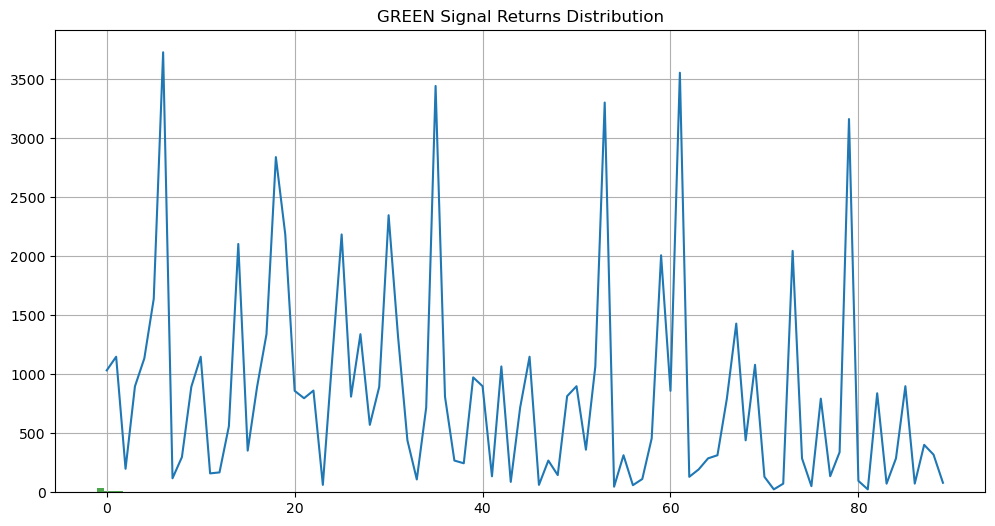

In [20]:
import pandas as pd
import os

filepath = r'C:\\Users\\Kuro Gaming\\Data Stience\\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows (raw):")
print(df.head())

# Compute features
df['returns'] = df['close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['volume_ma'] = df['volume'].rolling(20).mean()

df = df.dropna().reset_index(drop=True)

# Save ALL columns (including new ones)
df.to_csv('clean_trading_data.csv', index=False)

print("\nFirst few rows (with features):")
print(df.head())

print("\n✅ Trading signals processed successfully!")
print("Output saved as: clean_trading_data.csv")

df['returns'].hist(bins=50, alpha=0.7, color='green')
plt.title('Day 1: Trading Returns Distribution')
plt.savefig('returns_hist.png')

df['close'].plot(figsize=(12,6))
plt.title('Day 1: Price Time Series')
plt.savefig('price_series.png')

green_returns = df[df['signal']=='GREEN']['returns']
green_returns.hist(bins=30, alpha=0.7, color='lime')
plt.title('GREEN Signal Returns Distribution')
plt.savefig('green_returns_hist.png')

print(df[['returns', 'volatility']].describe())